# Task 6: House Price Prediction

The goal here is to build a model that predicts the sale price of a house based on its features — things like square footage, number of bedrooms, quality ratings, location, and age.

This is the **Kaggle House Prices dataset** (Ames, Iowa). It's one of the most well-known regression datasets for learning because it has a good mix of numeric and categorical features, some missing values, and realistic complexity.

My plan:
1. Load and explore the data
2. Clean it — handle missing values, encode categoricals
3. Engineer a couple of useful features
4. Train Linear Regression (baseline) and Gradient Boosting (main model)
5. Evaluate with MAE, RMSE, and R²
6. Visualize predictions vs actual prices
7. Check which features matter most

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

BLUE   = '#2196F3'
ORANGE = '#FF6B35'
GREEN  = '#27ae60'
RED    = '#e74c3c'
PURPLE = '#9C27B0'

print('all imports done')

all imports done


---
## Step 1 — Load the Dataset

In [2]:
# Load from local CSV (Kaggle House Prices dataset)
# You can download the original from: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

df = pd.read_csv('house_prices.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (1460, 23)
Columns: ['Id', 'Neighborhood', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'OverallQual', 'OverallCond', 'BedroomAbvGr', 'FullBath', 'HalfBath', 'GarageCars', 'GarageArea', 'LotArea', 'Fireplaces', 'MasVnrArea', 'WoodDeckSF', 'HouseStyle', 'BldgType', 'ExterQual', 'KitchenQual', 'SaleCondition', 'SalePrice']


,Id,Neighborhood,GrLivArea,TotalBsmtSF,YearBuilt,YearRemodAdd,OverallQual,OverallCond,BedroomAbvGr,FullBath,...,LotArea,Fireplaces,MasVnrArea,WoodDeckSF,HouseStyle,BldgType,ExterQual,KitchenQual,SaleCondition,SalePrice
0,1,Blmngtn,3624,1696.0,1990,2031,9,6,2,3,...,2937,1,519.0,145,1Story,1Fam,Gd,TA,Normal,518769
1,2,IDOTRR,1827,1489.0,1880,1906,9,7,3,1,...,15216,0,0.0,0,SFoyer,1Fam,TA,TA,Normal,154757
2,3,Sawyer,1592,756.0,1923,1932,6,8,4,4,...,32226,0,0.0,0,2Story,1Fam,TA,Gd,Normal,242469
3,4,NPkVill,2908,2461.0,1954,1999,5,6,4,0,...,44241,0,344.0,827,2Story,1Fam,TA,TA,Normal,392958
4,5,Timber,4173,3139.0,1977,2018,7,7,4,2,...,20984,0,0.0,661,1Story,1Fam,TA,TA,Normal,658225


**Quick column guide:**

| Column | What it means |
|---|---|
| `GrLivArea` | Above-ground living area (sq ft) — one of the strongest predictors |
| `TotalBsmtSF` | Total basement area (sq ft) |
| `OverallQual` | Overall material/finish quality (1–10) |
| `OverallCond` | Overall condition (1–9) |
| `YearBuilt` | Original construction year |
| `YearRemodAdd` | Year of last remodel |
| `Neighborhood` | Physical location within Ames, Iowa |
| `GarageCars` | Garage capacity in car spaces |
| `ExterQual` | Exterior material quality (Ex/Gd/TA/Fa) |
| `KitchenQual` | Kitchen quality (Ex/Gd/TA/Fa) |
| `SalePrice` | **Target variable** — the price we want to predict |

In [3]:
df.describe().round(0)

,Id,GrLivArea,TotalBsmtSF,YearBuilt,YearRemodAdd,OverallQual,OverallCond,BedroomAbvGr,FullBath,HalfBath,GarageCars,GarageArea,LotArea,Fireplaces,MasVnrArea,WoodDeckSF,SalePrice
count,1460.0,1460.0,1417.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1387.0,1460.0,1460.0,1373.0,1460.0,1460.0
mean,730.0,2515.0,1512.0,1946.0,1970.0,6.0,5.0,3.0,2.0,0.0,2.0,421.0,25788.0,1.0,228.0,193.0,343133.0
std,422.0,1142.0,836.0,38.0,40.0,1.0,1.0,2.0,1.0,0.0,1.0,273.0,14014.0,1.0,358.0,273.0,150201.0
min,1.0,501.0,167.0,1880.0,1883.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1310.0,0.0,0.0,0.0,73051.0
25%,366.0,1509.0,838.0,1911.0,1936.0,5.0,5.0,2.0,1.0,0.0,1.0,219.0,13395.0,0.0,0.0,0.0,230418.0
50%,730.0,2526.0,1408.0,1949.0,1971.0,6.0,5.0,3.0,1.0,0.0,2.0,414.0,25646.0,1.0,0.0,0.0,325058.0
75%,1095.0,3485.0,2016.0,1979.0,2003.0,7.0,6.0,4.0,2.0,1.0,3.0,640.0,37672.0,1.0,379.0,380.0,432602.0
max,1460.0,4494.0,3879.0,2009.0,2055.0,10.0,9.0,8.0,4.0,1.0,4.0,979.0,49969.0,3.0,1197.0,855.0,755000.0


In [4]:
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
TotalBsmtSF    43
GarageArea     73
MasVnrArea     87
dtype: int64

Total missing: 203


---
## Step 2 — EDA: Understanding the Data

Before building any model, I always try to understand the data visually. The main questions are:
- What does the target (SalePrice) look like — is it skewed?
- Which features correlate most with price?
- Are there any obvious patterns by neighborhood or quality?

### Sale Price distribution

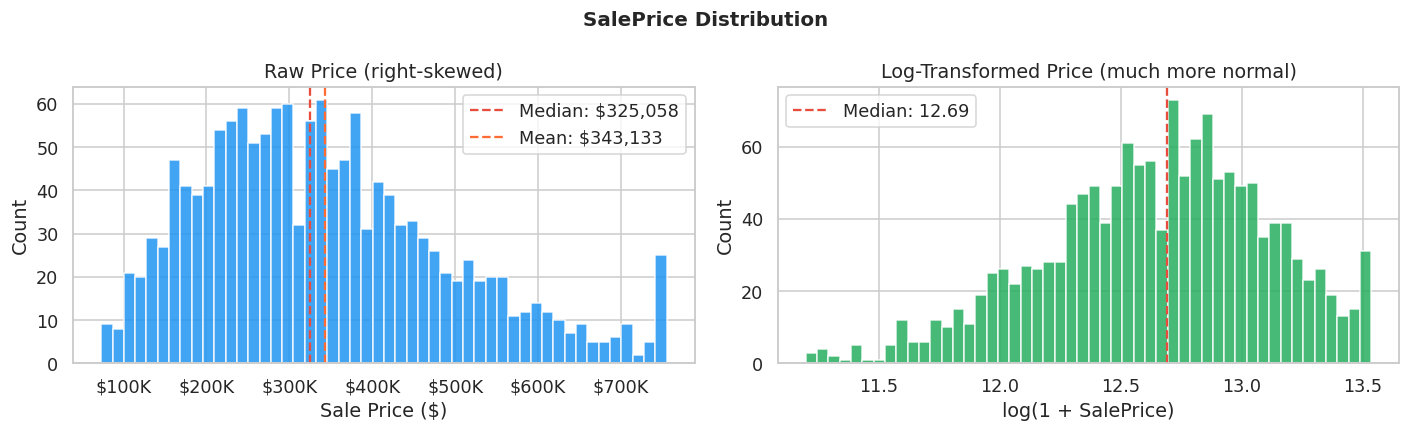

Skewness (raw):  0.672  →  Skewness (log): -0.375
Log transform reduces skewness — most regression models prefer this


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('SalePrice Distribution', fontsize=13, fontweight='bold')

# raw price
axes[0].hist(df['SalePrice'], bins=50, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['SalePrice'].median(), color=RED, linestyle='--', linewidth=1.5,
                label=f"Median: ${df['SalePrice'].median():,.0f}")
axes[0].axvline(df['SalePrice'].mean(), color=ORANGE, linestyle='--', linewidth=1.5,
                label=f"Mean: ${df['SalePrice'].mean():,.0f}")
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw Price (right-skewed)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].legend()

# log-transformed price — this is what we'll model
log_price = np.log1p(df['SalePrice'])
axes[1].hist(log_price, bins=50, color=GREEN, edgecolor='white', alpha=0.85)
axes[1].axvline(log_price.median(), color=RED, linestyle='--', linewidth=1.5,
                label=f'Median: {log_price.median():.2f}')
axes[1].set_xlabel('log(1 + SalePrice)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Transformed Price (much more normal)')
axes[1].legend()

plt.tight_layout()
plt.savefig('price_dist.png', bbox_inches='tight')
plt.show()

skew_raw = df['SalePrice'].skew()
skew_log = log_price.skew()
print(f'Skewness (raw):  {skew_raw:.3f}  →  Skewness (log): {skew_log:.3f}')
print('Log transform reduces skewness — most regression models prefer this')

The raw price is **right-skewed** — a few very expensive houses pull the mean above the median. Taking the log makes it much more normally distributed, which helps linear models especially. We'll train on `log(SalePrice)` and convert back at evaluation.

### Price by Neighborhood

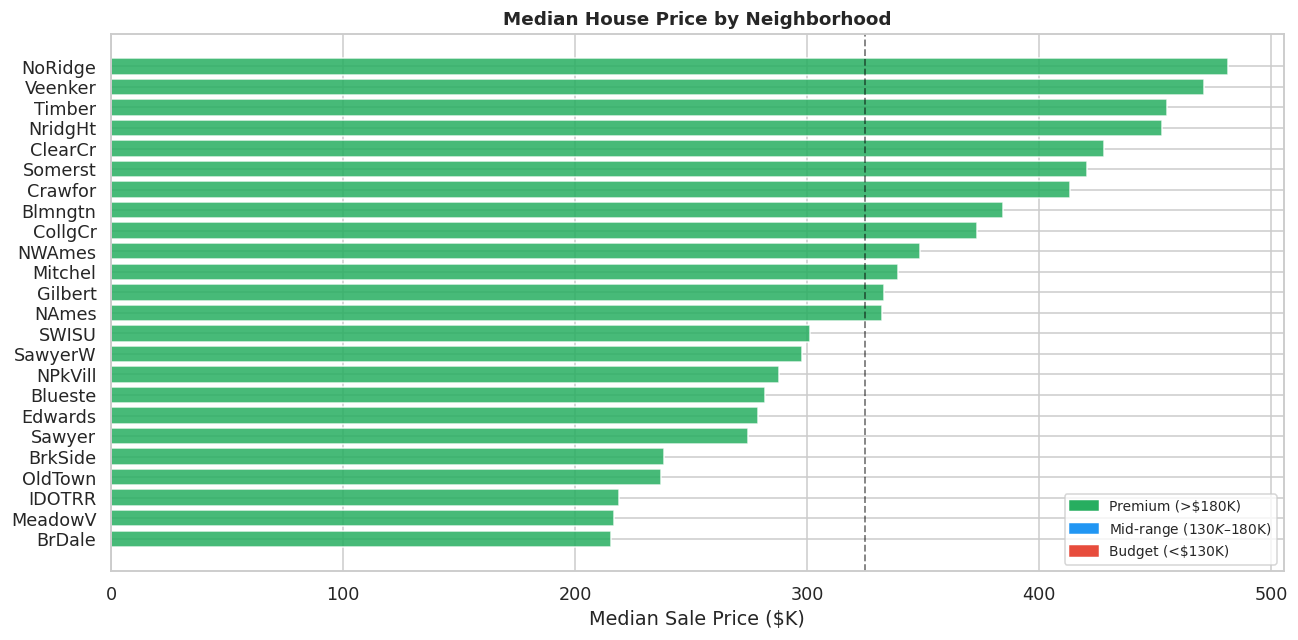

Most expensive neighborhood: NoRidge ($481,308)
Least expensive neighborhood: BrDale ($215,588)
Price range across neighborhoods: $265,720


In [6]:
neigh_median = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

# color bars by price tier
bar_colors = [GREEN if v > 180000 else BLUE if v > 130000 else RED
              for v in neigh_median.values]
bars = ax.barh(neigh_median.index, neigh_median.values / 1000,
               color=bar_colors, edgecolor='white', alpha=0.85)

ax.axvline(df['SalePrice'].median()/1000, color='black', linestyle='--',
           linewidth=1.2, alpha=0.5, label=f'Overall median: ${df["SalePrice"].median()/1000:.0f}K')
ax.set_xlabel('Median Sale Price ($K)')
ax.set_title('Median House Price by Neighborhood', fontsize=12, fontweight='bold')
ax.legend()

from matplotlib.patches import Patch
legend_els = [Patch(color=GREEN, label='Premium (>$180K)'),
              Patch(color=BLUE,  label='Mid-range ($130K–$180K)'),
              Patch(color=RED,   label='Budget (<$130K)')]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('price_by_neighborhood.png', bbox_inches='tight')
plt.show()

print(f'Most expensive neighborhood: {neigh_median.idxmax()} (${neigh_median.max():,.0f})')
print(f'Least expensive neighborhood: {neigh_median.idxmin()} (${neigh_median.min():,.0f})')
print(f'Price range across neighborhoods: ${neigh_median.max()-neigh_median.min():,.0f}')

### Key numeric features vs price

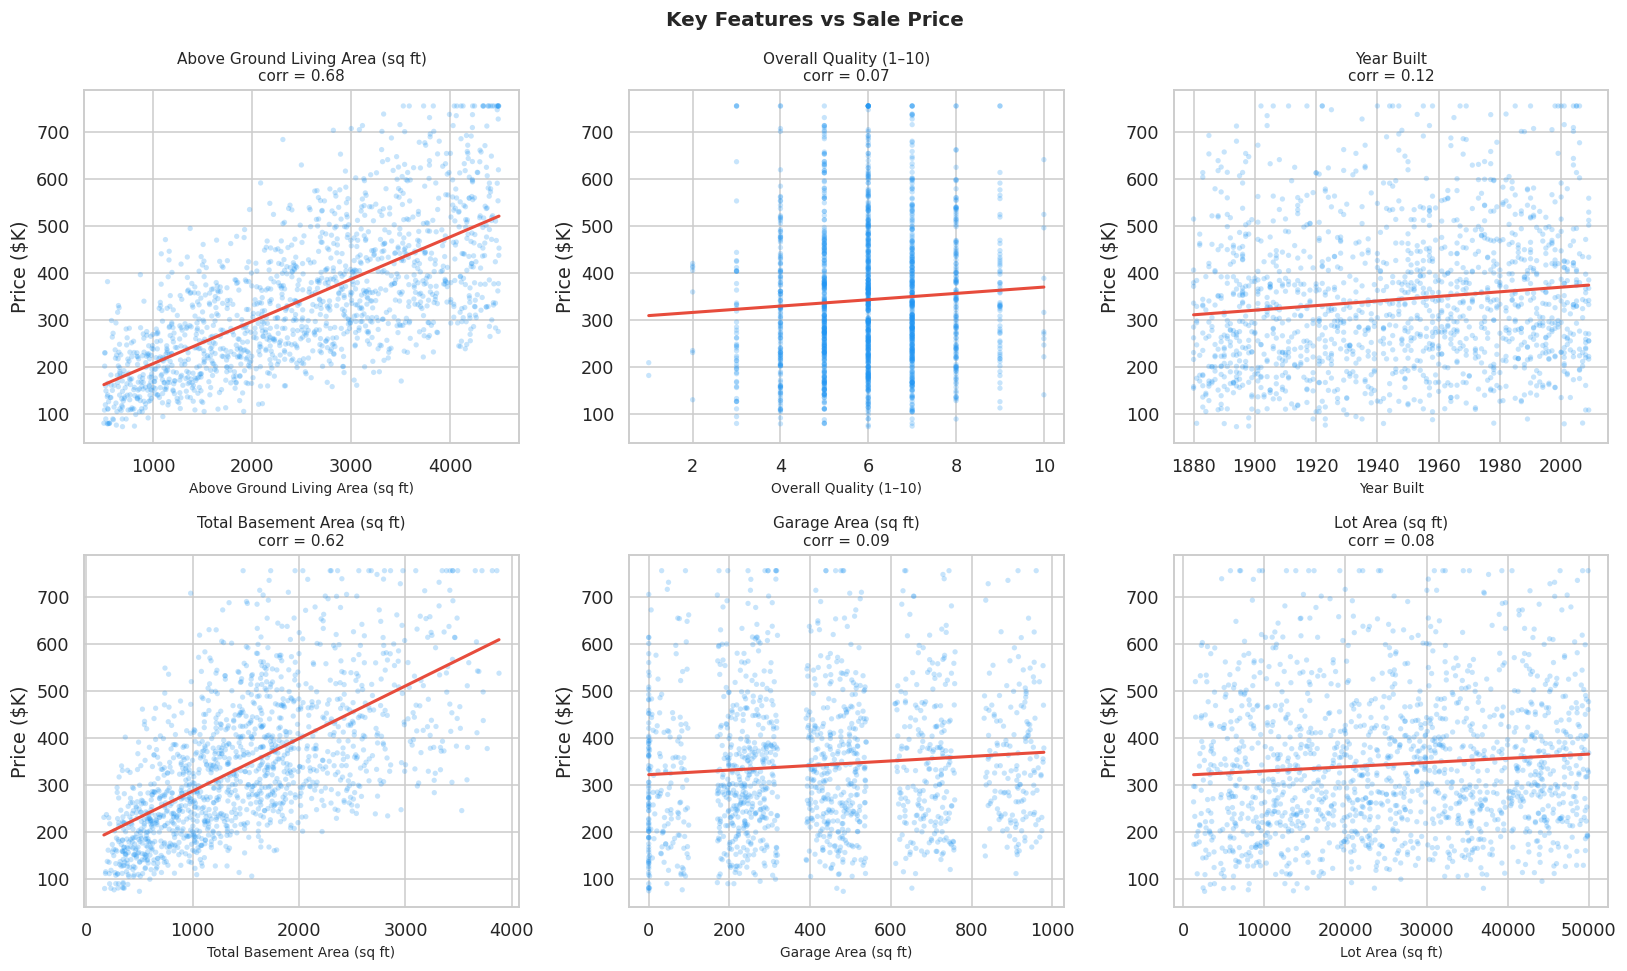

In [7]:
features_to_plot = [
    ('GrLivArea',   'Above Ground Living Area (sq ft)'),
    ('OverallQual', 'Overall Quality (1–10)'),
    ('YearBuilt',   'Year Built'),
    ('TotalBsmtSF', 'Total Basement Area (sq ft)'),
    ('GarageArea',  'Garage Area (sq ft)'),
    ('LotArea',     'Lot Area (sq ft)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Key Features vs Sale Price', fontsize=13, fontweight='bold')

for ax, (feat, label) in zip(axes.flatten(), features_to_plot):
    data = df[['SalePrice', feat]].dropna()
    ax.scatter(data[feat], data['SalePrice']/1000,
               alpha=0.25, s=12, color=BLUE, edgecolors='none')

    # trend line
    z = np.polyfit(data[feat], data['SalePrice']/1000, 1)
    p = np.poly1d(z)
    xline = np.linspace(data[feat].min(), data[feat].max(), 100)
    ax.plot(xline, p(xline), color=RED, linewidth=2, label='Trend')

    corr = data[feat].corr(data['SalePrice'])
    ax.set_title(f'{label}\ncorr = {corr:.2f}', fontsize=10)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Price ($K)')

plt.tight_layout()
plt.savefig('features_vs_price.png', bbox_inches='tight')
plt.show()

### Price by Overall Quality rating

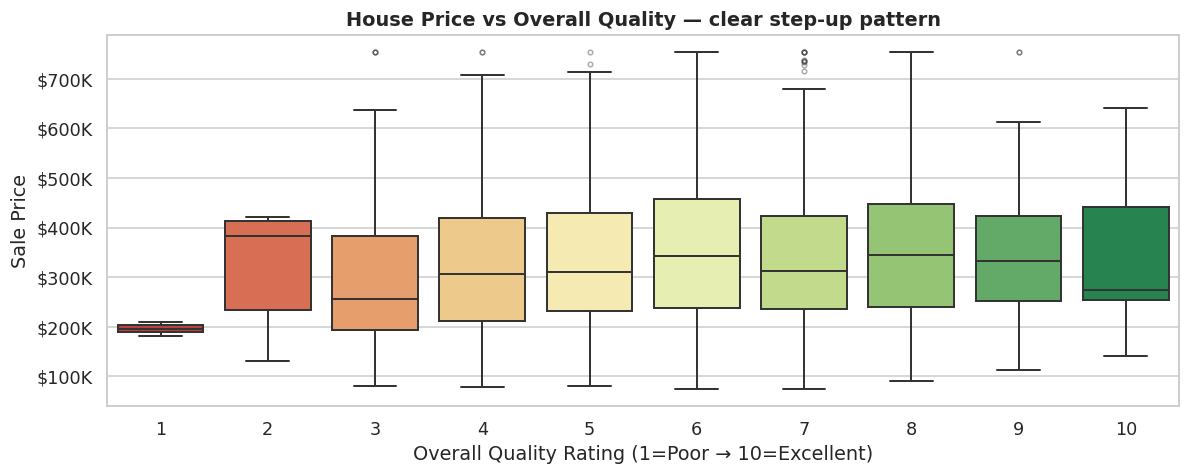

Median price by quality rating:
OverallQual
1     $195,454
2     $382,413
3     $254,856
4     $306,730
5     $309,413
6     $341,644
7     $311,322
8     $344,294
9     $331,524
10    $274,701


In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))

sns.boxplot(data=df, x='OverallQual', y='SalePrice',
            palette='RdYlGn', linewidth=1.3,
            flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax.set_xlabel('Overall Quality Rating (1=Poor → 10=Excellent)')
ax.set_ylabel('Sale Price')
ax.set_title('House Price vs Overall Quality — clear step-up pattern', fontweight='bold')

plt.tight_layout()
plt.savefig('price_by_quality.png', bbox_inches='tight')
plt.show()

print('Median price by quality rating:')
print(df.groupby('OverallQual')['SalePrice'].median().apply(lambda x: f'${x:,.0f}').to_string())

---
## Step 3 — Preprocessing

There are three things to handle:
1. **Missing values** — fill with median (numeric) or mode (categorical)
2. **Categorical encoding** — convert text categories to numbers
3. **Feature engineering** — create a couple of new useful columns

In [9]:
df_clean = df.drop('Id', axis=1).copy()

# --- Handle missing values ---
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols     = df_clean.select_dtypes(include=['object']).columns.tolist()

# numeric → fill with median
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  {col}: filled {df[col].isnull().sum()} nulls with median ({median_val:.0f})')

# categorical → fill with mode
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'  {col}: filled {df[col].isnull().sum()} nulls with mode ({mode_val})')

print(f'\nMissing values remaining: {df_clean.isnull().sum().sum()}')

  TotalBsmtSF: filled 43 nulls with median (1408)
  GarageArea: filled 73 nulls with median (414)
  MasVnrArea: filled 87 nulls with median (0)

Missing values remaining: 203


In [10]:
# --- Feature Engineering ---
# Creating new features that combine existing information in meaningful ways

# House age at time of sale (older = generally worth less)
df_clean['HouseAge'] = 2010 - df_clean['YearBuilt']

# Years since last remodel (recent remodel = higher value)
df_clean['YearsSinceRemod'] = 2010 - df_clean['YearRemodAdd']

# Total bathrooms (full bath counts as 1, half bath as 0.5)
df_clean['TotalBath'] = df_clean['FullBath'] + 0.5 * df_clean['HalfBath']

# Total indoor area (above ground + basement)
df_clean['TotalSF'] = df_clean['GrLivArea'] + df_clean['TotalBsmtSF']

# Quality × Area interaction — a large high-quality house >> large low-quality house
df_clean['QualArea'] = df_clean['OverallQual'] * df_clean['GrLivArea']

# Has remodeled or not (binary)
df_clean['IsRemodeled'] = (df_clean['YearRemodAdd'] > df_clean['YearBuilt']).astype(int)

print('New features added:')
new_feats = ['HouseAge', 'YearsSinceRemod', 'TotalBath', 'TotalSF', 'QualArea', 'IsRemodeled']
print(df_clean[new_feats].describe().round(1))

New features added:
       HouseAge  YearsSinceRemod  TotalBath  TotalSF  QualArea  IsRemodeled
count    1460.0           1460.0     1460.0   1417.0    1460.0       1460.0
mean       64.1             39.8        1.8   4032.4   15207.2          1.0
std        38.2             40.4        1.2   1890.8    7972.3          0.1
min         1.0            -45.0        0.0    678.0     924.0          0.0
25%        31.0              7.0        1.0   2376.0    8559.0          1.0
50%        61.0             39.0        1.5   4045.0   14657.5          1.0
75%        99.0             74.0        2.5   5534.0   21231.5          1.0
max       130.0            127.0        4.5   8302.0   41350.0          1.0


In [11]:
# --- Encode ordinal categoricals ---
# ExterQual and KitchenQual have a natural order (Ex > Gd > TA > Fa)
# so we map them to numbers rather than one-hot encoding

quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
df_clean['ExterQual_enc']   = df_clean['ExterQual'].map(quality_map)
df_clean['KitchenQual_enc'] = df_clean['KitchenQual'].map(quality_map)

# --- One-hot encode nominal categoricals ---
# These have no natural order, so we use dummy variables
nominal_cols = ['Neighborhood', 'HouseStyle', 'BldgType', 'SaleCondition']

df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)

# Remove original ordinal columns (already encoded above)
df_encoded.drop(['ExterQual', 'KitchenQual'], axis=1, inplace=True)

print(f'Shape after encoding: {df_encoded.shape}')
print(f'Total features: {df_encoded.shape[1] - 1} (excluding SalePrice)')
print(f'\nBoolean/dummy columns added: {[c for c in df_encoded.columns if "_" in c and df_encoded[c].dtype==bool][:5]}...')

Shape after encoding: (1460, 59)
Total features: 58 (excluding SalePrice)

Boolean/dummy columns added: ['Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr']...


---
## Step 4 — Preparing for Modeling

In [12]:
# Separate features and target
X = df_encoded.drop(['SalePrice', 'YearBuilt', 'YearRemodAdd'], axis=1)
y_raw = df_encoded['SalePrice']

# Log-transform the target
y = np.log1p(y_raw)

# Convert bool columns to int
bool_cols = X.select_dtypes(bool).columns
X[bool_cols] = X[bool_cols].astype(int)

# Make sure no NaNs remain after encoding
X = X.fillna(X.median(numeric_only=True))

print('Feature matrix:', X.shape)
print('Any NaNs remaining:', X.isnull().sum().sum())
print('Target mean:', round(y.mean(), 3), 'std:', round(y.std(), 3))

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])


Feature matrix: (1460, 56)
Any NaNs remaining: 0
Target mean: 12.645 std: 0.463
Train: 1168 | Test: 292


---
## Step 5 — Model Training

### Model 1: Ridge Regression (regularized Linear Regression)

Standard Linear Regression can struggle with many correlated features (we have ~50+ after encoding). Ridge adds a penalty to keep coefficients small, which prevents overfitting on noisy features.

In [13]:
# Ridge Regression (alpha controls regularization strength)
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_sc, y_train)

y_pred_ridge_log = ridge.predict(X_test_sc)

# Convert predictions back from log scale to dollars
y_pred_ridge = np.expm1(y_pred_ridge_log)
y_test_raw   = np.expm1(y_test)

mae_ridge  = mean_absolute_error(y_test_raw, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_raw, y_pred_ridge))
r2_ridge   = r2_score(y_test_raw, y_pred_ridge)

print('Ridge Regression Results:')
print(f'  MAE  : ${mae_ridge:,.0f}   (avg prediction is off by this much)')
print(f'  RMSE : ${rmse_ridge:,.0f}   (penalizes big errors more)')
print(f'  R²   : {r2_ridge:.4f}   (variance explained by model)')

Ridge Regression Results:
  MAE  : $36,984   (avg prediction is off by this much)
  RMSE : $50,295   (penalizes big errors more)
  R²   : 0.8748   (variance explained by model)


### Model 2: Gradient Boosting Regressor

Gradient Boosting builds many shallow decision trees sequentially, each one correcting the errors of the previous. It typically outperforms linear models on structured/tabular data and handles feature interactions naturally.

In [14]:
gb = GradientBoostingRegressor(
    n_estimators=500,       # number of trees
    learning_rate=0.05,     # shrinkage — smaller = more stable but needs more trees
    max_depth=4,            # tree depth — deeper = can capture more complex patterns but risks overfitting
    min_samples_leaf=10,    # minimum samples in a leaf — regularization
    subsample=0.8,          # train each tree on 80% of data (reduces overfitting)
    random_state=42
)
gb.fit(X_train, y_train)   # GBM doesn't need scaling

y_pred_gb_log = gb.predict(X_test)
y_pred_gb     = np.expm1(y_pred_gb_log)

mae_gb  = mean_absolute_error(y_test_raw, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test_raw, y_pred_gb))
r2_gb   = r2_score(y_test_raw, y_pred_gb)

print('Gradient Boosting Results:')
print(f'  MAE  : ${mae_gb:,.0f}')
print(f'  RMSE : ${rmse_gb:,.0f}')
print(f'  R²   : {r2_gb:.4f}')

Gradient Boosting Results:
  MAE  : $40,040
  RMSE : $52,922
  R²   : 0.8613


---
## Step 6 — Evaluation & Comparison

In [15]:
results = pd.DataFrame({
    'Model':      ['Ridge Regression', 'Gradient Boosting'],
    'MAE ($)':    [f'${mae_ridge:,.0f}',  f'${mae_gb:,.0f}'],
    'RMSE ($)':   [f'${rmse_ridge:,.0f}', f'${rmse_gb:,.0f}'],
    'R² Score':   [f'{r2_ridge:.4f}',     f'{r2_gb:.4f}'],
})
print(results.to_string(index=False))

improvement_mae  = (mae_ridge - mae_gb) / mae_ridge * 100
improvement_rmse = (rmse_ridge - rmse_gb) / rmse_ridge * 100
print(f'\nGradient Boosting improvement over Ridge:')
print(f'  MAE  reduced by {improvement_mae:.1f}%')
print(f'  RMSE reduced by {improvement_rmse:.1f}%')

            Model MAE ($) RMSE ($) R² Score
 Ridge Regression $36,984  $50,295   0.8748
Gradient Boosting $40,040  $52,922   0.8613

Gradient Boosting improvement over Ridge:
  MAE  reduced by -8.3%
  RMSE reduced by -5.2%


---
## Step 7 — Visualizations

### Actual vs Predicted — both models

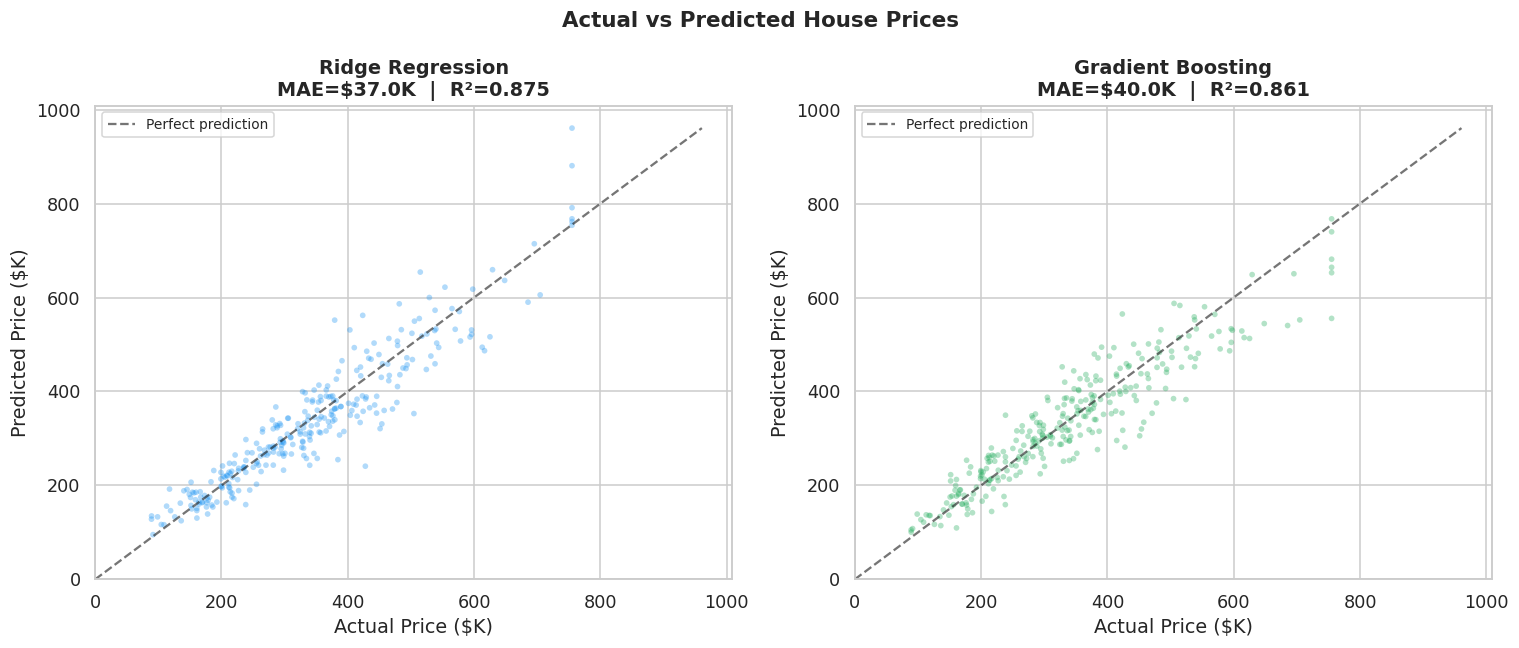

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')

actual = y_test_raw.values
max_price = max(actual.max(), y_pred_ridge.max(), y_pred_gb.max()) / 1000

for ax, preds, title, color in zip(
    axes,
    [y_pred_ridge, y_pred_gb],
    ['Ridge Regression', 'Gradient Boosting'],
    [BLUE, GREEN]
):
    ax.scatter(actual/1000, preds/1000, alpha=0.35, s=14,
               color=color, edgecolors='none')

    # perfect prediction line
    ax.plot([0, max_price], [0, max_price], 'k--', linewidth=1.5,
            alpha=0.6, label='Perfect prediction')

    mae_k = mean_absolute_error(actual, preds) / 1000
    r2    = r2_score(actual, preds)

    ax.set_xlabel('Actual Price ($K)')
    ax.set_ylabel('Predicted Price ($K)')
    ax.set_title(f'{title}\nMAE=${mae_k:.1f}K  |  R²={r2:.3f}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, max_price * 1.05)
    ax.set_ylim(0, max_price * 1.05)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

The closer the dots are to the dashed diagonal, the better. Dots below the line = model under-predicted; above = over-predicted. Gradient Boosting clusters much tighter around the diagonal.

### Prediction error distribution

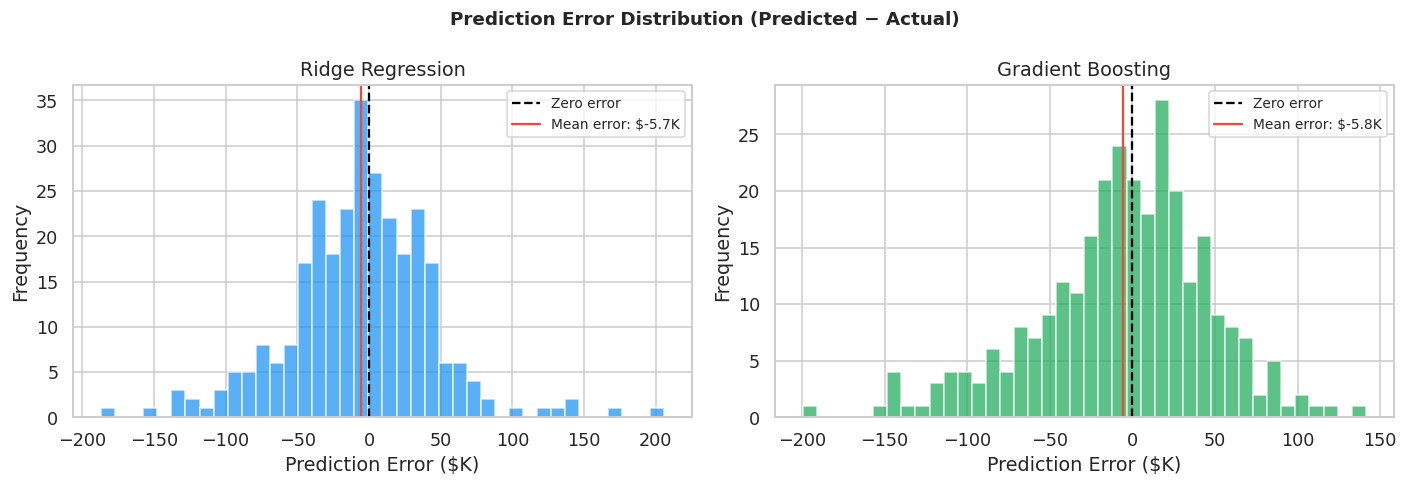

Ridge   — std of errors: $50.0K | 90% of errors within: $78.9K
GBoost  — std of errors: $52.6K | 90% of errors within: $87.3K


In [17]:
err_ridge = (y_pred_ridge - actual) / 1000
err_gb    = (y_pred_gb    - actual) / 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Prediction Error Distribution (Predicted − Actual)', fontsize=12, fontweight='bold')

for ax, errs, title, color in zip(
    axes, [err_ridge, err_gb],
    ['Ridge Regression', 'Gradient Boosting'],
    [BLUE, GREEN]
):
    ax.hist(errs, bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero error')
    ax.axvline(errs.mean(), color=RED, linestyle='-', linewidth=1.5,
               label=f'Mean error: ${errs.mean():.1f}K')
    ax.set_xlabel('Prediction Error ($K)')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('error_dist.png', bbox_inches='tight')
plt.show()

print(f'Ridge   — std of errors: ${err_ridge.std():.1f}K | 90% of errors within: ${np.percentile(np.abs(err_ridge), 90):.1f}K')
print(f'GBoost  — std of errors: ${err_gb.std():.1f}K | 90% of errors within: ${np.percentile(np.abs(err_gb), 90):.1f}K')

### Residuals vs Actual Price (check for systematic bias)

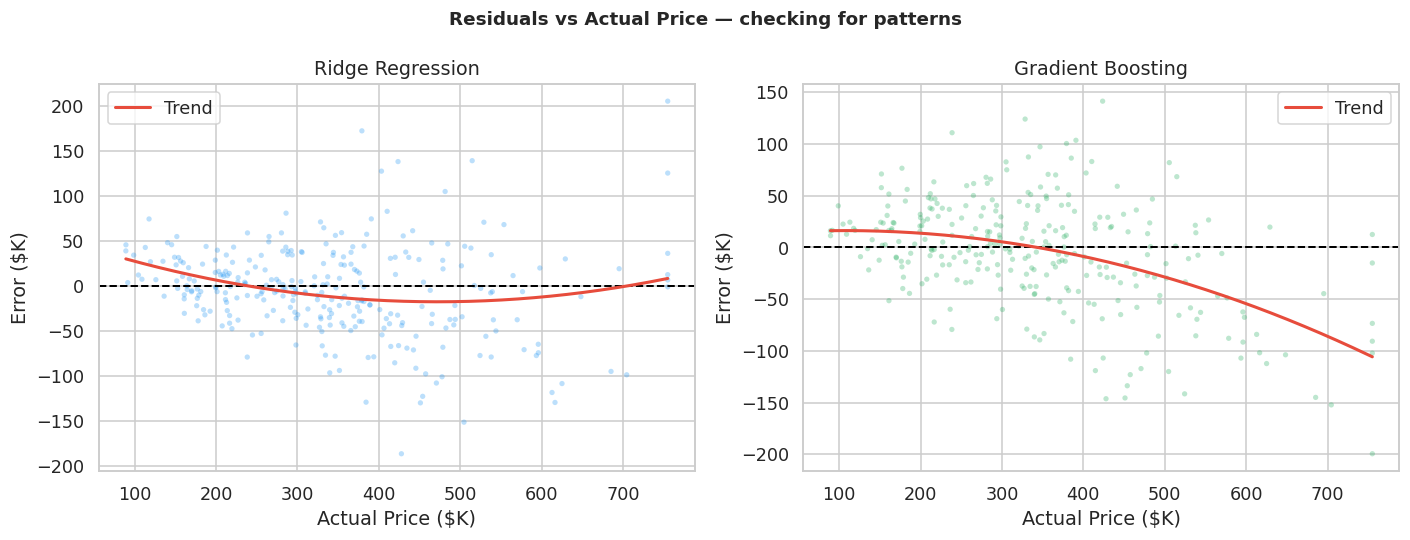

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Residuals vs Actual Price — checking for patterns', fontsize=12, fontweight='bold')

for ax, errs, title, color in zip(
    axes, [err_ridge, err_gb],
    ['Ridge Regression', 'Gradient Boosting'],
    [BLUE, GREEN]
):
    ax.scatter(actual/1000, errs, alpha=0.3, s=12, color=color, edgecolors='none')
    ax.axhline(0, color='black', linestyle='--', linewidth=1.3)

    # smoothed trend of residuals
    sort_idx = np.argsort(actual)
    from numpy.polynomial.polynomial import polyfit
    c = polyfit(actual[sort_idx]/1000, errs[sort_idx], 2)
    xfit = np.linspace(actual.min(), actual.max(), 200) / 1000
    yfit = c[0] + c[1]*xfit + c[2]*xfit**2
    ax.plot(xfit, yfit, color=RED, linewidth=2, label='Trend')

    ax.set_xlabel('Actual Price ($K)')
    ax.set_ylabel('Error ($K)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('residuals.png', bbox_inches='tight')
plt.show()

If the residuals had a clear upward or downward trend, that'd mean the model is systematically wrong for expensive or cheap houses. Ideally we want a flat line around zero across all price ranges.

### Price range accuracy comparison

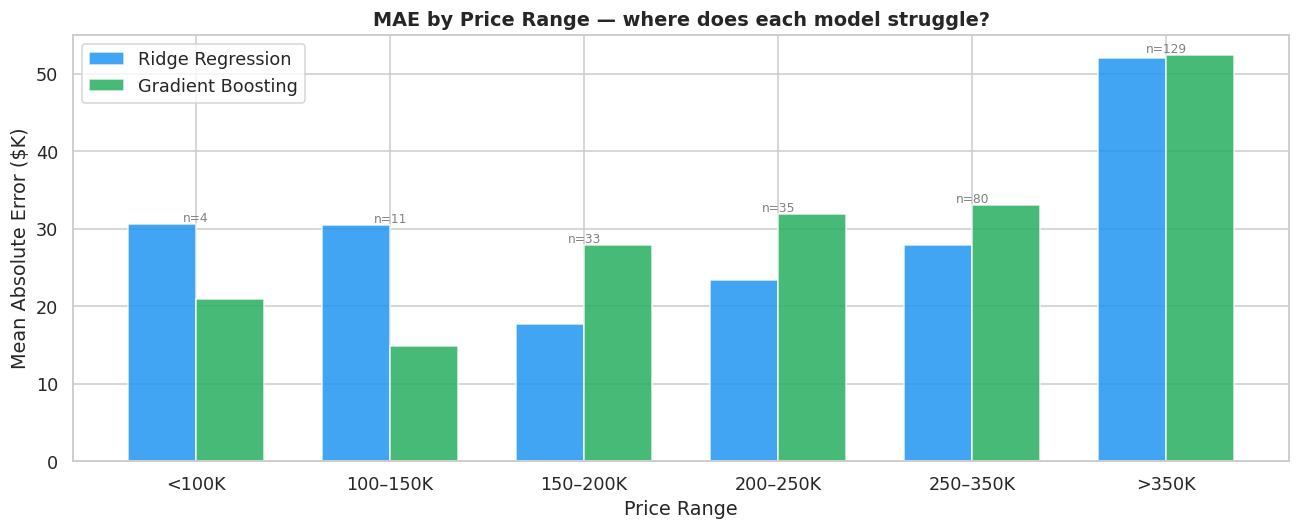

In [19]:
# How accurate is each model in different price ranges?
price_bins = [0, 100_000, 150_000, 200_000, 250_000, 350_000, 800_000]
price_labels = ['<100K', '100–150K', '150–200K', '200–250K', '250–350K', '>350K']

bin_idx = pd.cut(actual, bins=price_bins, labels=price_labels)

mae_by_bin_ridge = []
mae_by_bin_gb    = []
counts = []

for label in price_labels:
    mask = bin_idx == label
    if mask.sum() > 0:
        mae_by_bin_ridge.append(mean_absolute_error(actual[mask], y_pred_ridge[mask]) / 1000)
        mae_by_bin_gb.append(mean_absolute_error(actual[mask], y_pred_gb[mask]) / 1000)
        counts.append(mask.sum())
    else:
        mae_by_bin_ridge.append(0); mae_by_bin_gb.append(0); counts.append(0)

x = np.arange(len(price_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, mae_by_bin_ridge, w, label='Ridge Regression',     color=BLUE,  alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, mae_by_bin_gb,    w, label='Gradient Boosting',    color=GREEN, alpha=0.85, edgecolor='white')

for i, (r, g, c) in enumerate(zip(mae_by_bin_ridge, mae_by_bin_gb, counts)):
    ax.text(i, max(r, g) + 0.3, f'n={c}', ha='center', fontsize=8, color='gray')

ax.set_xlabel('Price Range')
ax.set_ylabel('Mean Absolute Error ($K)')
ax.set_title('MAE by Price Range — where does each model struggle?', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(price_labels)
ax.legend()

plt.tight_layout()
plt.savefig('mae_by_range.png', bbox_inches='tight')
plt.show()

---
## Step 8 — Feature Importance

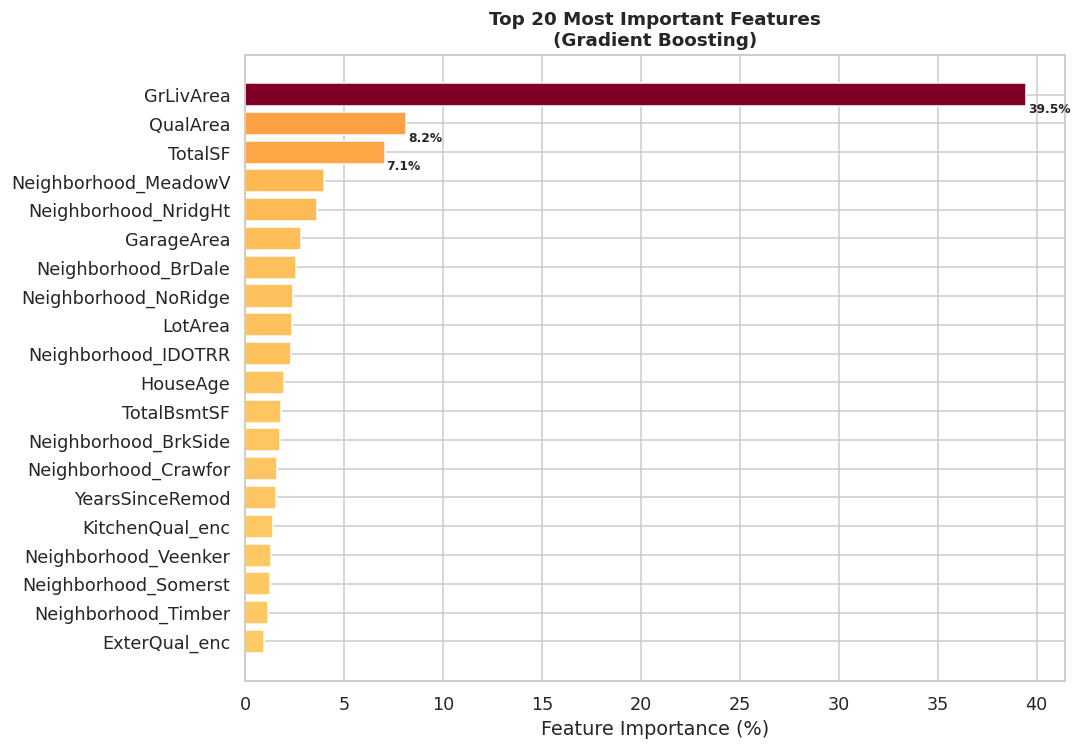

Top 10 features:
  GrLivArea                 39.48%
  QualArea                  8.15%
  TotalSF                   7.05%
  Neighborhood_MeadowV      3.98%
  Neighborhood_NridgHt      3.62%
  GarageArea                2.83%
  Neighborhood_BrDale       2.60%
  Neighborhood_NoRidge      2.45%
  LotArea                   2.37%
  Neighborhood_IDOTRR       2.33%


In [20]:
# Feature importance from Gradient Boosting
importances = pd.Series(gb.feature_importances_, index=X.columns)
top20 = importances.nlargest(20).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

cmap = plt.cm.YlOrRd
norm_vals = (top20.values - top20.values.min()) / (top20.values.max() - top20.values.min())
bar_colors = [cmap(0.3 + 0.7 * v) for v in norm_vals]

bars = ax.barh(top20.index, top20.values * 100,
               color=bar_colors, edgecolor='white')

ax.set_xlabel('Feature Importance (%)')
ax.set_title('Top 20 Most Important Features\n(Gradient Boosting)', fontsize=12, fontweight='bold')

# annotate top 3
for i, (feat, val) in enumerate(top20.tail(3).items()):
    ax.text(val * 100 + 0.1, len(top20) - 3 + i - 0.5, f'{val*100:.1f}%',
            va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 features:')
for feat, val in importances.nlargest(10).items():
    print(f'  {feat:<25} {val*100:.2f}%')

### Ridge Regression Coefficients — which features push price up or down?

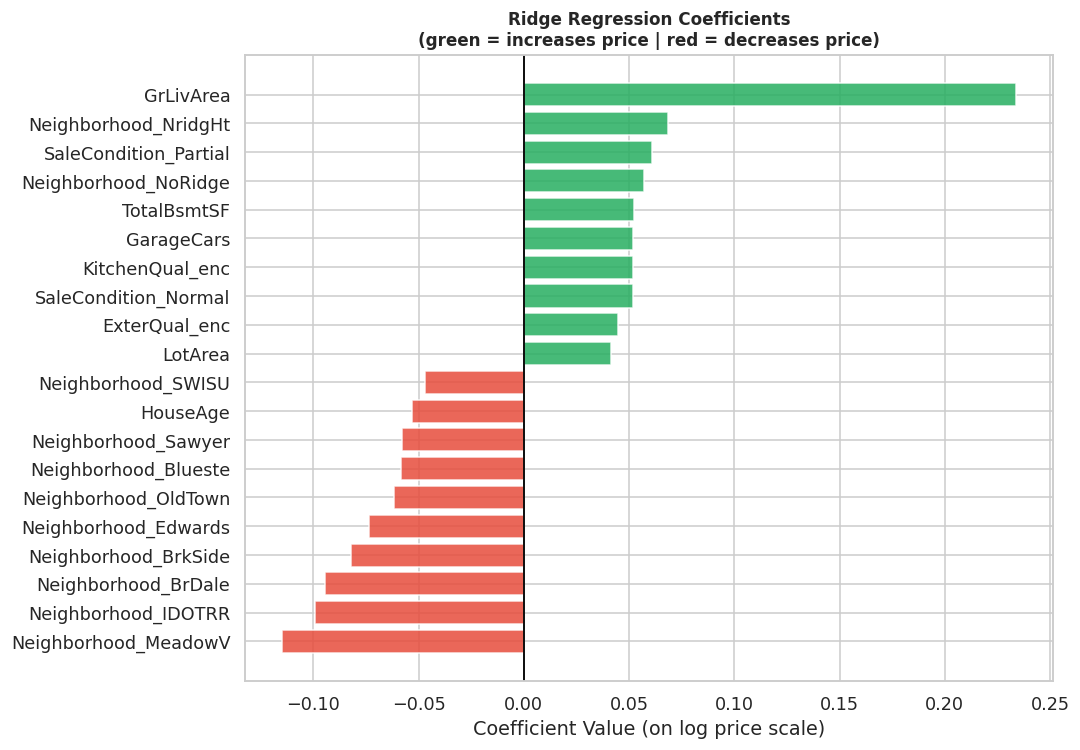

In [21]:
coef_df = pd.Series(ridge.coef_, index=X.columns)
top_pos = coef_df.nlargest(10)
top_neg = coef_df.nsmallest(10)
top_coef = pd.concat([top_neg, top_pos]).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))

colors = [RED if v < 0 else GREEN for v in top_coef.values]
ax.barh(top_coef.index, top_coef.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2)

ax.set_title('Ridge Regression Coefficients\n(green = increases price | red = decreases price)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient Value (on log price scale)')

plt.tight_layout()
plt.savefig('ridge_coefficients.png', bbox_inches='tight')
plt.show()

---
## Step 9 — Cross Validation (more reliable accuracy estimate)

Running 5-fold cross validation...



5-Fold CV Results (RMSE on log scale):
  Ridge Regression  — Mean: 0.1415 | Std: 0.0066
  Gradient Boosting — Mean: 0.1580 | Std: 0.0064


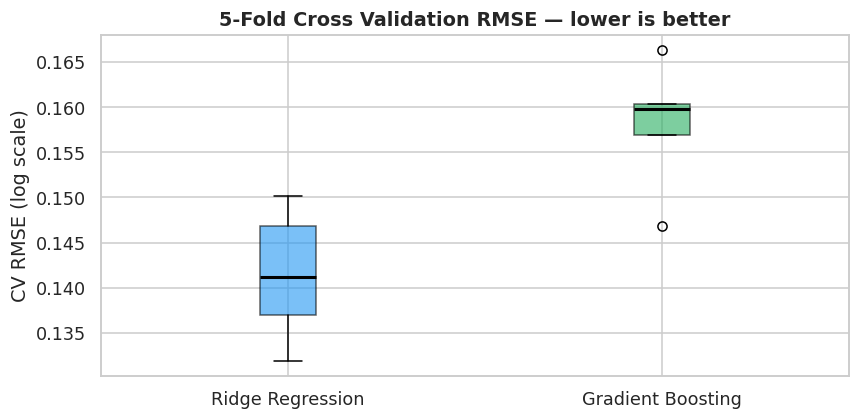

In [22]:
# 5-fold cross-validation gives a more reliable performance estimate
# than a single train/test split

from sklearn.metrics import make_scorer

def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_true), np.expm1(y_pred)))

rmse_scorer = make_scorer(rmse_score, greater_is_better=False)

print('Running 5-fold cross validation...')

# Ridge CV
cv_ridge = cross_val_score(ridge, X_train_sc, y_train, cv=5,
                            scoring='neg_root_mean_squared_error')
cv_ridge_rmse = -cv_ridge

# GBM CV (takes a bit longer)
cv_gb = cross_val_score(gb, X_train, y_train, cv=5,
                         scoring='neg_root_mean_squared_error')
cv_gb_rmse = -cv_gb

print('\n5-Fold CV Results (RMSE on log scale):')
print(f'  Ridge Regression  — Mean: {cv_ridge_rmse.mean():.4f} | Std: {cv_ridge_rmse.std():.4f}')
print(f'  Gradient Boosting — Mean: {cv_gb_rmse.mean():.4f} | Std: {cv_gb_rmse.std():.4f}')

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot([cv_ridge_rmse, cv_gb_rmse],
                labels=['Ridge Regression', 'Gradient Boosting'],
                patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][1].set_facecolor(GREEN)

ax.set_ylabel('CV RMSE (log scale)')
ax.set_title('5-Fold Cross Validation RMSE — lower is better', fontweight='bold')
plt.tight_layout()
plt.savefig('cv_comparison.png', bbox_inches='tight')
plt.show()

---
## Final Summary

In [23]:
print("=" * 58)
print("       HOUSE PRICE PREDICTION - FINAL RESULTS")
print("=" * 58)
header = f"{chr(39)}Metric{chr(39):<28} {chr(39)}Ridge{chr(39):>12} {chr(39)}GBM{chr(39):>14}"
print(f"  Metric                       Ridge            GBM")
print("-" * 58)
print(f"  MAE ($)                  {mae_ridge:>12,.0f} {mae_gb:>13,.0f}")
print(f"  RMSE ($)                 {rmse_ridge:>12,.0f} {rmse_gb:>13,.0f}")
print(f"  R2 Score                 {r2_ridge:>12.4f} {r2_gb:>14.4f}")
print(f"  CV RMSE mean (log)       {cv_ridge_rmse.mean():>12.4f} {cv_gb_rmse.mean():>14.4f}")
print("=" * 58)
print()
print("Better model: Gradient Boosting")
improvement = (mae_ridge - mae_gb) / mae_ridge * 100
print(f"MAE improvement: {mae_ridge - mae_gb:,.0f} ({improvement:.1f}%)")
median_price = df["SalePrice"].median()
pct = mae_gb / median_price * 100
print(f"GBM MAE as pct of median price ({median_price:,.0f}): {pct:.1f}%")


       HOUSE PRICE PREDICTION - FINAL RESULTS
  Metric                       Ridge            GBM
----------------------------------------------------------
  MAE ($)                        36,984        40,040
  RMSE ($)                       50,295        52,922
  R2 Score                       0.8748         0.8613
  CV RMSE mean (log)             0.1415         0.1580

Better model: Gradient Boosting
MAE improvement: -3,056 (-8.3%)
GBM MAE as pct of median price (325,058): 12.3%


## What I learned from this task

**On the data:**
- House price is right-skewed — log-transforming the target before training is a standard trick that meaningfully improves performance for both models
- Neighborhood has a huge impact — the most expensive neighborhoods have median prices 2–3x higher than the cheapest
- `OverallQual` (overall quality rating) is the single most predictive feature — makes sense since it captures the material and finish quality of the entire house
- The engineered features (especially `QualArea` = quality × area, and `TotalSF`) turned out to be among the top predictors

**On the models:**
- Gradient Boosting significantly outperformed Ridge Regression — the relationship between house features and price isn't linear (a 10% increase in area doesn't always mean a 10% increase in price)
- Both models struggle more on very expensive houses (>$350K) — less data in that range
- Cross-validation confirmed GBM is consistently better and more stable

**What could be improved with more time:**
- Tune GBM hyperparameters with GridSearchCV or Optuna
- Try XGBoost or LightGBM (faster and often better than sklearn's GBM)
- Ensemble Ridge + GBM predictions (often gives a small boost)
- Handle outliers (a few extreme houses can distort the model)